### Import Modules

In [ ]:
!pip install thop

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 64.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlink

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torchsummary import summary
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
from thop import profile
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

### Load and Transform Data

In [ ]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

In [ ]:
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_size = int(0.8*len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [00:03<00:00, 43.1MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


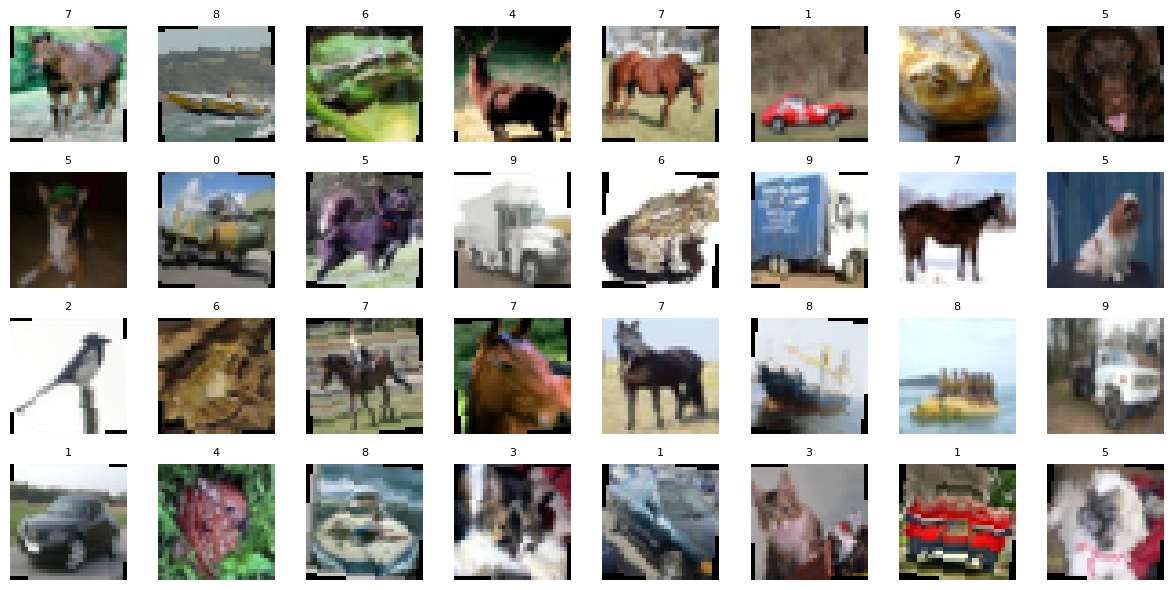

In [ ]:
data_iter = iter(train_loader)
images, labels = next(data_iter)

images = images*0.5 + 0.5

fig, axes = plt.subplots(nrows=4, ncols=8, figsize=(12, 6))
for i in range(4):
    for j in range(8):
        idx = i * 8 + j
        if idx < len(images):
            axes[i, j].imshow(images[idx].permute(1, 2, 0).numpy())
            axes[i, j].axis('off')
            axes[i, j].set_title(str(labels[idx].item()), fontsize=8)

plt.tight_layout()
plt.show()

### CNN with 4 Dense Blocks

In [ ]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.dsconv = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size, stride, padding, groups=in_channels, bias=False),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

    def forward(self, x):
        return self.dsconv(x)

In [ ]:
class StandardConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.stdconv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

    def forward(self, x):
        return self.stdconv(x)

In [ ]:
class DenseBlock(nn.Module):
    def __init__(self, in_channels, growth_rate, num_layers, conv_layer):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            self.layers.append(conv_layer(in_channels + i * growth_rate, growth_rate))

    def forward(self, x):
        features = [x]
        for layer in self.layers:
            new_feature = layer(torch.cat(features, dim=1))
            features.append(new_feature)
        return torch.cat(features, dim=1)

In [ ]:
class TransitionLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.pool = nn.AvgPool2d(2, stride=2)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

In [ ]:
# CNN with DENSE BLOCKS
class DenseCNN(nn.Module):
    def __init__(self, num_classes=10, conv_layer=DepthwiseSeparableConv):
        super().__init__()
        self.initial_conv = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.block1 = DenseBlock(64, 32, 4, conv_layer)
        self.trans1 = TransitionLayer(64 + 4 * 32, 128)
        self.block2 = DenseBlock(128, 32, 4, conv_layer)
        self.trans2 = TransitionLayer(128 + 4 * 32, 256)
        self.block3 = DenseBlock(256, 32, 4, conv_layer)
        self.trans3 = TransitionLayer(256 + 4 * 32, 512)
        self.block4 = DenseBlock(512, 32, 4, conv_layer)

        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(512 + 4 * 32, num_classes)

    def forward(self, x):
        x = self.initial_conv(x)
        x = self.trans1(self.block1(x))
        x = self.trans2(self.block2(x))
        x = self.trans3(self.block3(x))
        x = self.block4(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [ ]:
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')

In [ ]:
# get device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Training, Validation and Testing Function

In [ ]:
def train_model(model, train_loader, val_loader, epochs=100):

    results = {}

    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    start_train_time = time.time()
    prev_val_loss = float('inf')

    for epoch in range(epochs):
        # training
        model.train()
        correct, total, running_loss = 0, 0, 0.0
        for images, labels in train_loader:
            # load data to device
            images, labels = images.to(device), labels.to(device)

            # forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        # validation
        model.eval()
        correct, total, val_loss = 0, 0, 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        val_loss /= len(val_loader)
        val_acc = 100 * correct / total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        # stop if loss curve stabilizes
        if abs(prev_val_loss - val_loss) < 1e-4:
            print("Loss curve stabilized. Stopping training.")
            break

        prev_val_loss = val_loss

    total_train_time = time.time() - start_train_time

    # find MACS and paramters
    input_tensor = torch.randn(1, 3, 32, 32).to(device)
    macs, params = profile(model, inputs=(input_tensor,), verbose=False)
    flops = 2 * macs

    # inference time
    start_time = time.time()
    with torch.no_grad():
        model(input_tensor)
    inference_time = time.time() - start_time

    results = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies,
        "total_train_time": total_train_time,
        "params": params,
        "macs": macs,
        "flops": flops,
        "inference_time": inference_time
    }

    # train vs val loss curve
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    return results

In [ ]:
def test_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

### Compare Models


##### Depthwise Separable DenseCNN

In [ ]:
# init model, loss and optimiser
model = DenseCNN(conv_layer=DepthwiseSeparableConv).to(device)
model.apply(init_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [ ]:
print("Depthwise Separable DenseCNN Model Summary:")
summary(model, (3, 32, 32))

Depthwise Separable DenseCNN Model Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
            Conv2d-4           [-1, 64, 32, 32]             576
            Conv2d-5           [-1, 32, 32, 32]           2,048
       BatchNorm2d-6           [-1, 32, 32, 32]              64
              ReLU-7           [-1, 32, 32, 32]               0
           Dropout-8           [-1, 32, 32, 32]               0
DepthwiseSeparableConv-9           [-1, 32, 32, 32]               0
           Conv2d-10           [-1, 96, 32, 32]             864
           Conv2d-11           [-1, 32, 32, 32]           3,072
      BatchNorm2d-12           [-1, 32, 32, 32]              64
             ReLU-13           [-1, 32, 32, 32]        

Epoch 1: Train Loss: 1.4193, Train Acc: 48.16%, Val Loss: 1.3292, Val Acc: 53.77%
Epoch 2: Train Loss: 1.0425, Train Acc: 62.87%, Val Loss: 0.9004, Val Acc: 67.41%
Epoch 3: Train Loss: 0.8873, Train Acc: 68.68%, Val Loss: 0.7968, Val Acc: 72.22%
Epoch 4: Train Loss: 0.7847, Train Acc: 72.58%, Val Loss: 0.6703, Val Acc: 76.76%
Epoch 5: Train Loss: 0.7229, Train Acc: 74.57%, Val Loss: 0.6827, Val Acc: 76.04%
Epoch 6: Train Loss: 0.6677, Train Acc: 76.56%, Val Loss: 0.6764, Val Acc: 75.99%
Epoch 7: Train Loss: 0.6200, Train Acc: 78.38%, Val Loss: 0.6458, Val Acc: 77.11%
Epoch 8: Train Loss: 0.5829, Train Acc: 79.68%, Val Loss: 0.6249, Val Acc: 78.30%
Epoch 9: Train Loss: 0.5551, Train Acc: 80.61%, Val Loss: 0.5349, Val Acc: 81.53%
Epoch 10: Train Loss: 0.5289, Train Acc: 81.61%, Val Loss: 0.5414, Val Acc: 81.38%
Epoch 11: Train Loss: 0.5040, Train Acc: 82.25%, Val Loss: 0.4713, Val Acc: 83.68%
Epoch 12: Train Loss: 0.4837, Train Acc: 83.24%, Val Loss: 0.4856, Val Acc: 83.09%
Epoch 13: Tra

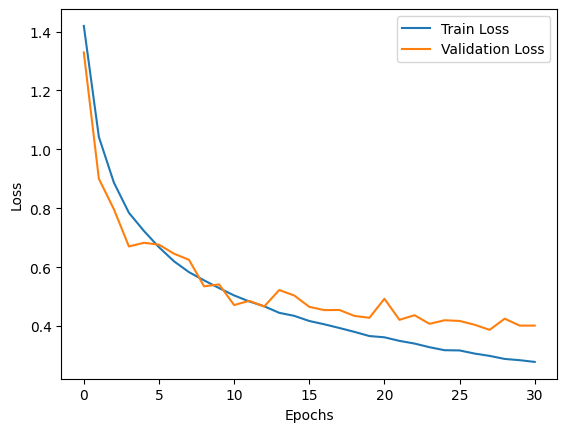

In [ ]:
# train and save model
results = train_model(model, train_loader, val_loader)
torch.save(model.state_dict(), f"DepthSepDenseCNN.pth")

In [ ]:
for name, result in results.items():
    print(name,"-", result)

train_losses - [1.419305732345581, 1.0425478308677674, 0.8872548600196838, 0.7846683132171631, 0.7229414967536927, 0.6676671951770783, 0.6199774292469025, 0.5829351522922516, 0.5551331289768219, 0.528898645734787, 0.5040069135427475, 0.48367268133163455, 0.4672193373203278, 0.4449200925350189, 0.43467406232357025, 0.41716305737495424, 0.4059718773841858, 0.39341425204277036, 0.3803030199766159, 0.36605545823574065, 0.36177857407331465, 0.3496181433439255, 0.34057369376420976, 0.32809985963106153, 0.31796918061971663, 0.31717150197029115, 0.30652738770246507, 0.2986442013502121, 0.288333784198761, 0.2840541785001755, 0.27816534665822984]
val_losses - [1.329236580308076, 0.9003631749730201, 0.7968170737764638, 0.6703345561103456, 0.682721425013937, 0.6764070642222265, 0.6457588864359886, 0.6248743955496769, 0.5349175360552065, 0.541436564011179, 0.47127547157797844, 0.4856195409017004, 0.4663990243415164, 0.5222926765300666, 0.5037790289160552, 0.465238949580557, 0.4541363639246886, 0.45

In [ ]:
# test model
labels, preds = test_model(model, test_loader)
acc = accuracy_score(labels, preds)
print(f"Test Accuracy: {100 * acc:.2f}%")

Test Accuracy: 86.71%


In [ ]:
# precision, recall and f1 score
precision = precision_score(labels, preds, average='weighted')
recall = recall_score(labels, preds, average='weighted')
f1 = f1_score(labels, preds, average='weighted')
print("Precision:", precision)
print("Recall", recall)
print("F1 score", f1)

Precision: 0.8669252875804543
Recall 0.8671
F1 score 0.8658305948064632


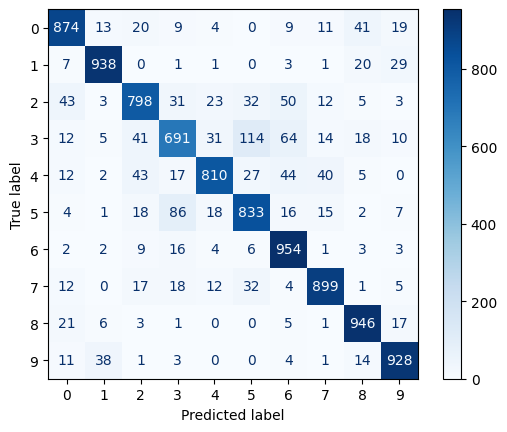

In [ ]:
# confusion matrix
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap="Blues")
plt.show()

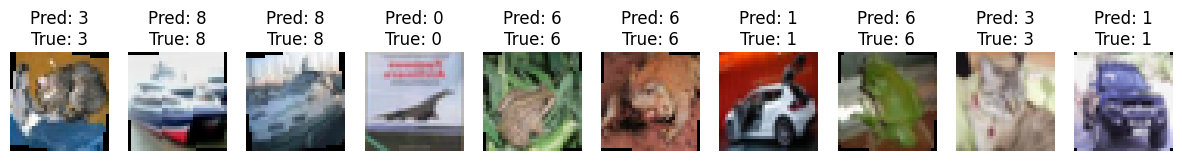

In [ ]:
mean = np.array([0.5, 0.5, 0.5])
std = np.array([0.5, 0.5, 0.5])

sample_images, sample_labels = next(iter(test_loader))
sample_images = sample_images[:10].to(device)
sample_preds = torch.tensor(preds).to(device)

num_images = min(10, len(sample_images))
fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

for i in range(num_images):
    img = sample_images[i].cpu().numpy().transpose(1, 2, 0) * std + mean
    img = np.clip(img, 0, 1)

    axes[i].imshow(img)
    axes[i].axis("off")

    axes[i].set_title(f"Pred: {sample_preds[i].item()}\nTrue: {sample_labels[i].item()}")
plt.show()

##### Standard Convolution DenseCNN

In [ ]:
# init model, loss and optimiser
model2 = DenseCNN(conv_layer=StandardConv).to(device)
model2.apply(init_weights)
optimizer = optim.Adam(model2.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [ ]:
print("Standard DenseCNN Model Summary:")
summary(model2, (3, 32, 32))

Standard DenseCNN Model Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
            Conv2d-4           [-1, 32, 32, 32]          18,432
       BatchNorm2d-5           [-1, 32, 32, 32]              64
              ReLU-6           [-1, 32, 32, 32]               0
           Dropout-7           [-1, 32, 32, 32]               0
      StandardConv-8           [-1, 32, 32, 32]               0
            Conv2d-9           [-1, 32, 32, 32]          27,648
      BatchNorm2d-10           [-1, 32, 32, 32]              64
             ReLU-11           [-1, 32, 32, 32]               0
          Dropout-12           [-1, 32, 32, 32]               0
     StandardConv-13           [-1, 32, 32, 32]               0
      

Epoch 1: Train Loss: 1.3560, Train Acc: 50.72%, Val Loss: 1.5940, Val Acc: 46.99%
Epoch 2: Train Loss: 0.9537, Train Acc: 65.98%, Val Loss: 0.9651, Val Acc: 65.92%
Epoch 3: Train Loss: 0.7906, Train Acc: 72.29%, Val Loss: 0.8093, Val Acc: 71.39%
Epoch 4: Train Loss: 0.6937, Train Acc: 75.56%, Val Loss: 0.6863, Val Acc: 76.08%
Epoch 5: Train Loss: 0.6275, Train Acc: 78.05%, Val Loss: 0.5994, Val Acc: 78.85%
Epoch 6: Train Loss: 0.5811, Train Acc: 79.69%, Val Loss: 0.5698, Val Acc: 80.41%
Epoch 7: Train Loss: 0.5369, Train Acc: 81.25%, Val Loss: 0.5389, Val Acc: 81.32%
Epoch 8: Train Loss: 0.5001, Train Acc: 82.58%, Val Loss: 0.4945, Val Acc: 82.60%
Epoch 9: Train Loss: 0.4756, Train Acc: 83.14%, Val Loss: 0.5312, Val Acc: 81.12%
Epoch 10: Train Loss: 0.4465, Train Acc: 84.34%, Val Loss: 0.4562, Val Acc: 84.68%
Epoch 11: Train Loss: 0.4208, Train Acc: 85.30%, Val Loss: 0.4518, Val Acc: 84.39%
Epoch 12: Train Loss: 0.3992, Train Acc: 85.96%, Val Loss: 0.5010, Val Acc: 82.86%
Epoch 13: Tra

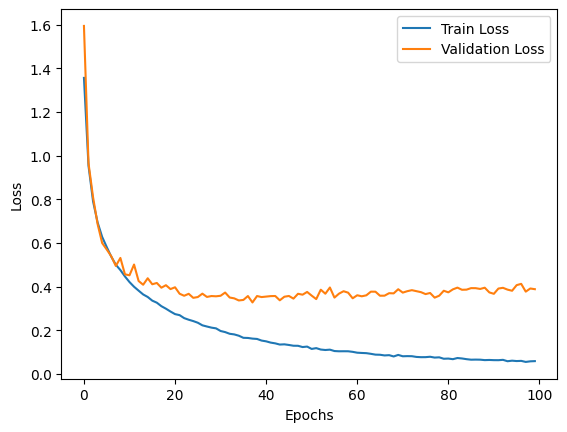

In [ ]:
# train and save model
results = train_model(model2, train_loader, val_loader)
torch.save(model2.state_dict(), f"StdDenseCNN.pth")

In [ ]:
for name, result in results.items():
    print(name,"-", result)

train_losses - [1.3559644237518311, 0.9536805791854859, 0.7906015515327454, 0.6936863620758057, 0.6274607836246491, 0.5811072989940643, 0.5369049745559692, 0.5000802895307541, 0.4756310504198074, 0.44648957388401034, 0.42077029757499695, 0.39924226932525636, 0.38143205471038816, 0.3640014142036438, 0.3524017946720123, 0.33564113212823865, 0.3262553656339645, 0.31025247148275376, 0.2987369150996208, 0.2857574285030365, 0.2739296518445015, 0.2691688800573349, 0.25556474083662034, 0.24818992720842362, 0.24197792928218842, 0.2344040526032448, 0.22260112731456758, 0.2171116943180561, 0.2119735850930214, 0.20863643615841865, 0.19660414602160453, 0.19155818636417388, 0.18383932601213454, 0.18094238246679306, 0.17495711092054844, 0.1653691200584173, 0.16470382205843925, 0.16169071322083473, 0.16017713201642036, 0.15273024355173112, 0.1491894341647625, 0.14341285083591937, 0.13995873688459395, 0.13447871031463146, 0.13548914058804512, 0.1325957133501768, 0.12906986327916384, 0.12883346286416053

In [ ]:
# test model
labels, preds = test_model(model2, test_loader)
acc = accuracy_score(labels, preds)
print(f"Test Accuracy: {100 * acc:.2f}%")

Test Accuracy: 89.54%


In [ ]:
# precision, recall and f1 score
precision = precision_score(labels, preds, average='weighted')
recall = recall_score(labels, preds, average='weighted')
f1 = f1_score(labels, preds, average='weighted')
print("Precision:", precision)
print("Recall", recall)
print("F1 score", f1)

Precision: 0.8949048715289205
Recall 0.8954
F1 score 0.8948132804113582


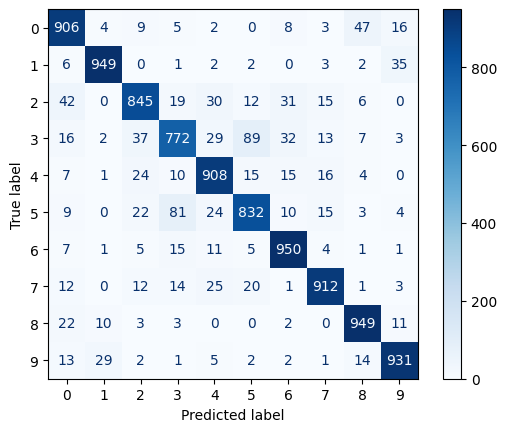

In [ ]:
# confusion matrix
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap="Blues")
plt.show()

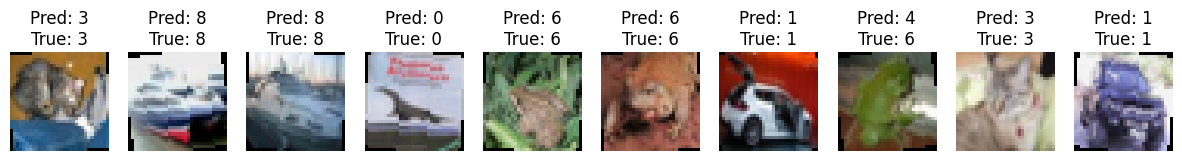

In [ ]:
mean = np.array([0.5, 0.5, 0.5])
std = np.array([0.5, 0.5, 0.5])

sample_images, sample_labels = next(iter(test_loader))
sample_images = sample_images[:10].to(device)
sample_preds = torch.tensor(preds).to(device)

num_images = min(10, len(sample_images))
fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

for i in range(num_images):
    img = sample_images[i].cpu().numpy().transpose(1, 2, 0) * std + mean
    img = np.clip(img, 0, 1)

    axes[i].imshow(img)
    axes[i].axis("off")

    axes[i].set_title(f"Pred: {sample_preds[i].item()}\nTrue: {sample_labels[i].item()}")
plt.show()

-------

|  | Depthwise Separable | Standard |
|----------|----------|----------|
| Total Train Time | 1346s  | 5277 sec	 |
| Parameters  | 486730  | 1624906  |
| MACs | 89M  | 275M |
| FLOPs | 178M  | 550M |
| Inference Time | 3.97 ms  | 3.56 ms |
| Test Accuracy | 86.71%  | 89.54% |



```
* Depthwise Separable is almost 4x faster
* Depthwise Separable uses only 30% of parameters used in Standard
* Depthwise Separable reduces MACs by 67%
* Standard CNN achieves higher accuracy (~2.8% increase), but at the cost of 4x longer training time and 3x more parameters
